In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

print(df.shape)
print(df.columns.tolist())

(6708, 29)
['season', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']


In [3]:
df_sg = df[df['pos'] == 'SG'].copy()

print("Nombre de SG :", df_sg.shape[0])

Nombre de SG : 1522


On utilise les statistiques préséléctionnées:

In [4]:
sg_stats = [ "usg_percent",
    "ts_percent",
    "x3p_ar",
    "f_tr",
    "ast_percent",
    "stl_percent",
    "tov_percent"]

X_sg = df_sg[sg_stats]

On met les stastiques à la même échelle avant d'éviter une influence excessive des données brutes des données relatives. 

In [5]:
scaler = StandardScaler()
X_sg_scaled = scaler.fit_transform(X_sg)

On utilise les PCA (Principal Component Analysis) pour résumer les statistiques utilisés en quelques axes synthétiques et ainsi pouvoir visualiser quelles statistiques permettent de classer les joueurs. On fixe la variance cumulée au moins à 0,7 afin d'être suffisament précis pour classer les joueurs de façons pertinentes sans rentrer dans des groupes ultra spécifiques. 

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_sg_scaled)

explained_var = pca.explained_variance_ratio_

cumulative_var = np.cumsum(explained_var)

print(explained_var)
print(cumulative_var)

[0.37444071 0.18888209 0.14028046 0.11643196 0.09806684 0.05138343
 0.0305145 ]
[0.37444071 0.56332281 0.70360326 0.82003523 0.91810207 0.9694855
 1.        ]


On prendra donc 3 PCA pour les SG.

In [7]:
pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_sg_scaled)


loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=sg_stats
)

print("Loadings PCA :")
print(loadings)

Loadings PCA :
                 PCA1      PCA2      PCA3
usg_percent  0.401514  0.464963 -0.266370
ts_percent  -0.093576  0.587333  0.669334
x3p_ar      -0.475473  0.137907  0.308712
f_tr         0.438900  0.192079  0.066072
ast_percent  0.483191  0.177026  0.142226
stl_percent  0.205651 -0.444055  0.518118
tov_percent  0.368180 -0.392956  0.304461


On cherche à determiner le nombre de clusters le plus pertinent pour le poste à l'aide de la méthode du coude et du score de silouhette . 

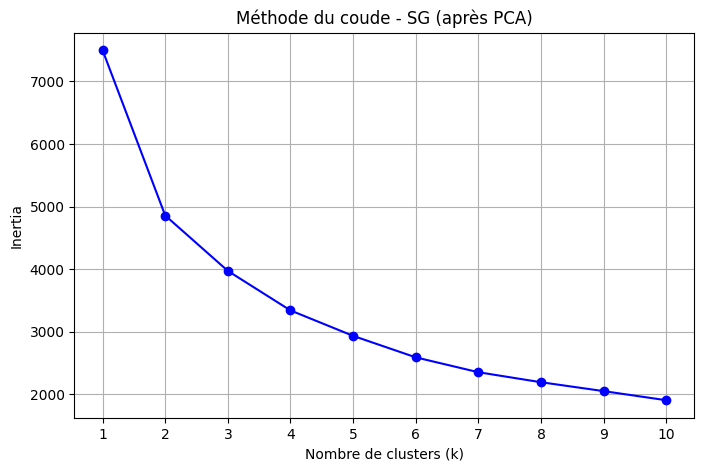

In [8]:
inertia_list = []

k_values = range(1, 11)


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_result) 
    inertia_list.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - SG (après PCA)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [9]:
inertia_c = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_c

,k,inertia
0,1,7496.189162
1,2,4856.951982
2,3,3972.646793
3,4,3341.459856
4,5,2935.378807
5,6,2592.155642
6,7,2354.743642
7,8,2194.994911
8,9,2053.124271
9,10,1907.588372


In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd


silhouette_scores = []


for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_result)  # <- utiliser le résultat PCA
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)


silhouette_df = pd.DataFrame({
    'k': range(2, 11),
    'silhouette_score': silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.318340
1,3,0.286307
2,4,0.241205
3,5,0.231062
4,6,0.245823
5,7,0.238271
6,8,0.227234
7,9,0.222672
8,10,0.230431


Le nombre de cluster le plus pertinent est donc 3 . 

In [11]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_sg['cluster'] = kmeans.fit_predict(pca_result) 

In [12]:
cluster_means = df_sg.groupby('cluster')[sg_stats].mean()
cluster_means

,usg_percent,ts_percent,x3p_ar,f_tr,ast_percent,stl_percent,tov_percent
cluster,,,,,,,
0,25.216393,0.554679,0.340403,0.294993,20.068618,1.569555,11.998361
1,17.570950,0.514405,0.364475,0.227587,14.472346,2.071788,14.105028
2,17.627273,0.555958,0.546875,0.163185,10.082768,1.428494,9.584396


Interprétation des clusters par les statistiques les plus influentes:
_cluster 0: usage moyen, bon pourcentage de shoot, tire énormément à 3 points (56%!), passe peu et perd peu de ballons. 
Profil type du SG tireur éxtérieur. 
_cluster 1: usage élevé, bon pourcentage de shoot, tire modérément à 3 points, attaque plus la raquette et provoque des fautes, il privilégie la création de jeu pour les équipiers (fort taux d'assist) et de steal (bon défenseur). Bpm positif. 
profil type du SG star/créateur pour les autres. 
_cluster 2: usage moyen, pourcentage de shoots faible, peu de tirs à 3 points, de passes, joueur moyen de manière générale, joueur de rotation avec un très mauvais BPM.

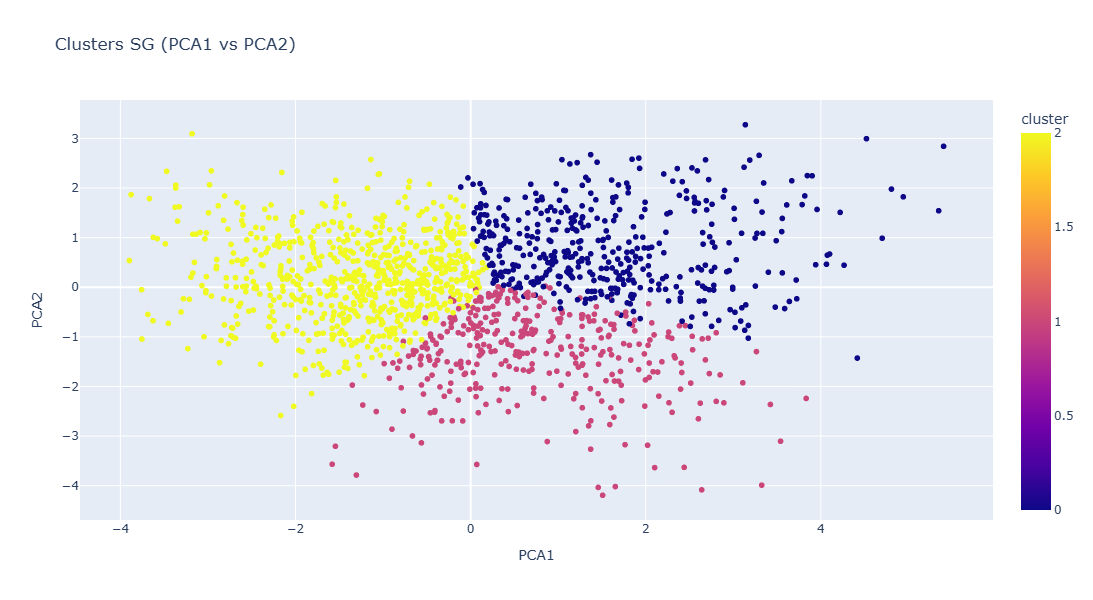

In [13]:
import plotly.express as px
import pandas as pd


plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'cluster': df_sg['cluster'],
    'player': df_sg['player'],
    'team': df_sg['team'],
    'season': df_sg['season']
})


fig = px.scatter(
    plot_df,
    x='PCA1',
    y='PCA2',
    color='cluster',
    hover_data=['player', 'team', 'season'],
    title="Clusters SG (PCA1 vs PCA2)",
    width=900,
    height=600
)

fig.show()

In [14]:
df_sg['cluster'] = kmeans.fit_predict(pca_result) 


df_sg.to_csv("../data/processed/nba_sg_clusters_full.csv", index=False)

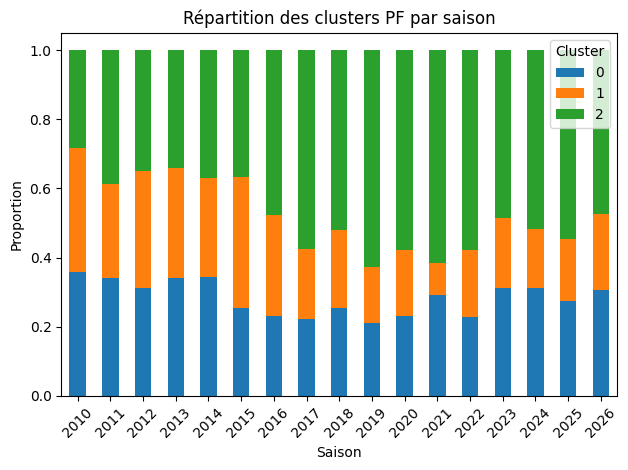

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df_sg = pd.read_csv("../data/processed/nba_sg_clusters_full.csv")

counts = df_sg.groupby(['season', 'cluster']).size().reset_index(name='count')

totals = df_sg.groupby('season').size().reset_index(name='total')

counts = counts.merge(totals, on='season')
counts['proportion'] = counts['count'] / counts['total']

pivot = counts.pivot(index='season', columns='cluster', values='proportion')

pivot.plot(kind='bar', stacked=True)

plt.title("Répartition des clusters SF par saison")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Il s'agit finalement du poste ayant le moins évolué sur la période étudié. Le nombre de PF de type 2 s'est progressivement imposé dans la ligue. Les deux autres types ont quant à eux légérements déclinés. 